In [1]:
import io
import json
import math
import os
from datetime import datetime

import matplotlib.cm as cm
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from PIL import Image
from torch import nn
from torch.nn import functional as F
from visualizations import visualize_attention, visualize_attention_on_images
from model import ViTForClassfication
from datasets import MNISTDataset, CIFAR10Dataset
import torch
from torch import nn, optim
from experiments import save_experiment, save_checkpoint
import logging


In [2]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

In [3]:
dataset = CIFAR10Dataset()
trainloader, testloader, classes = dataset.get_loaders(batch_size=128, num_workers=4)

/Users/valefeve/Projects/interpretable-transformers/venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [4]:
INDICES = [10, 12, 34, 46, 100]

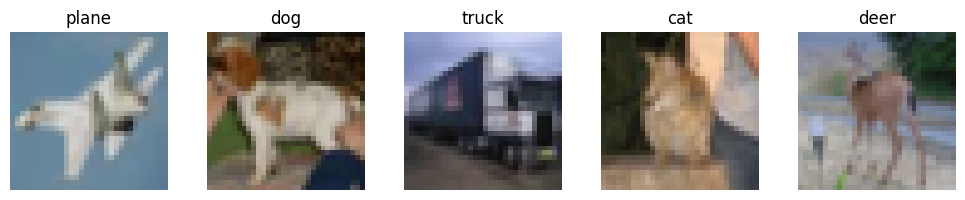

In [5]:
dataset.visualize_sample(indices=INDICES)

In [6]:
config = {
    "patch_size": 4,  # Input image size: 32x32 -> 8x8 patches
    "hidden_size": 48,
    "num_hidden_layers": 4,
    "num_attention_heads": 4,
    "intermediate_size": 4 * 48, # 4 * hidden_size
    "hidden_dropout_prob": 0.0,
    "attention_probs_dropout_prob": 0.0,
    "initializer_range": 0.02,
    "image_size": 32,
    "num_classes": 10, # num_classes of CIFAR10
    "num_channels": 3,
    "qkv_bias": True,
    "use_faster_attention": False,
}

model = ViTForClassfication(config).to(device)


In [7]:
dataset.get_samples_from_indices(INDICES)[0].shape

torch.Size([5, 3, 32, 32])

In [8]:
random_input = dataset.get_samples_from_indices(INDICES)[0].to(device)
logits, attention_maps = model(random_input, output_attentions=True)

In [9]:
attention_maps[0].shape

torch.Size([5, 4, 65, 65])

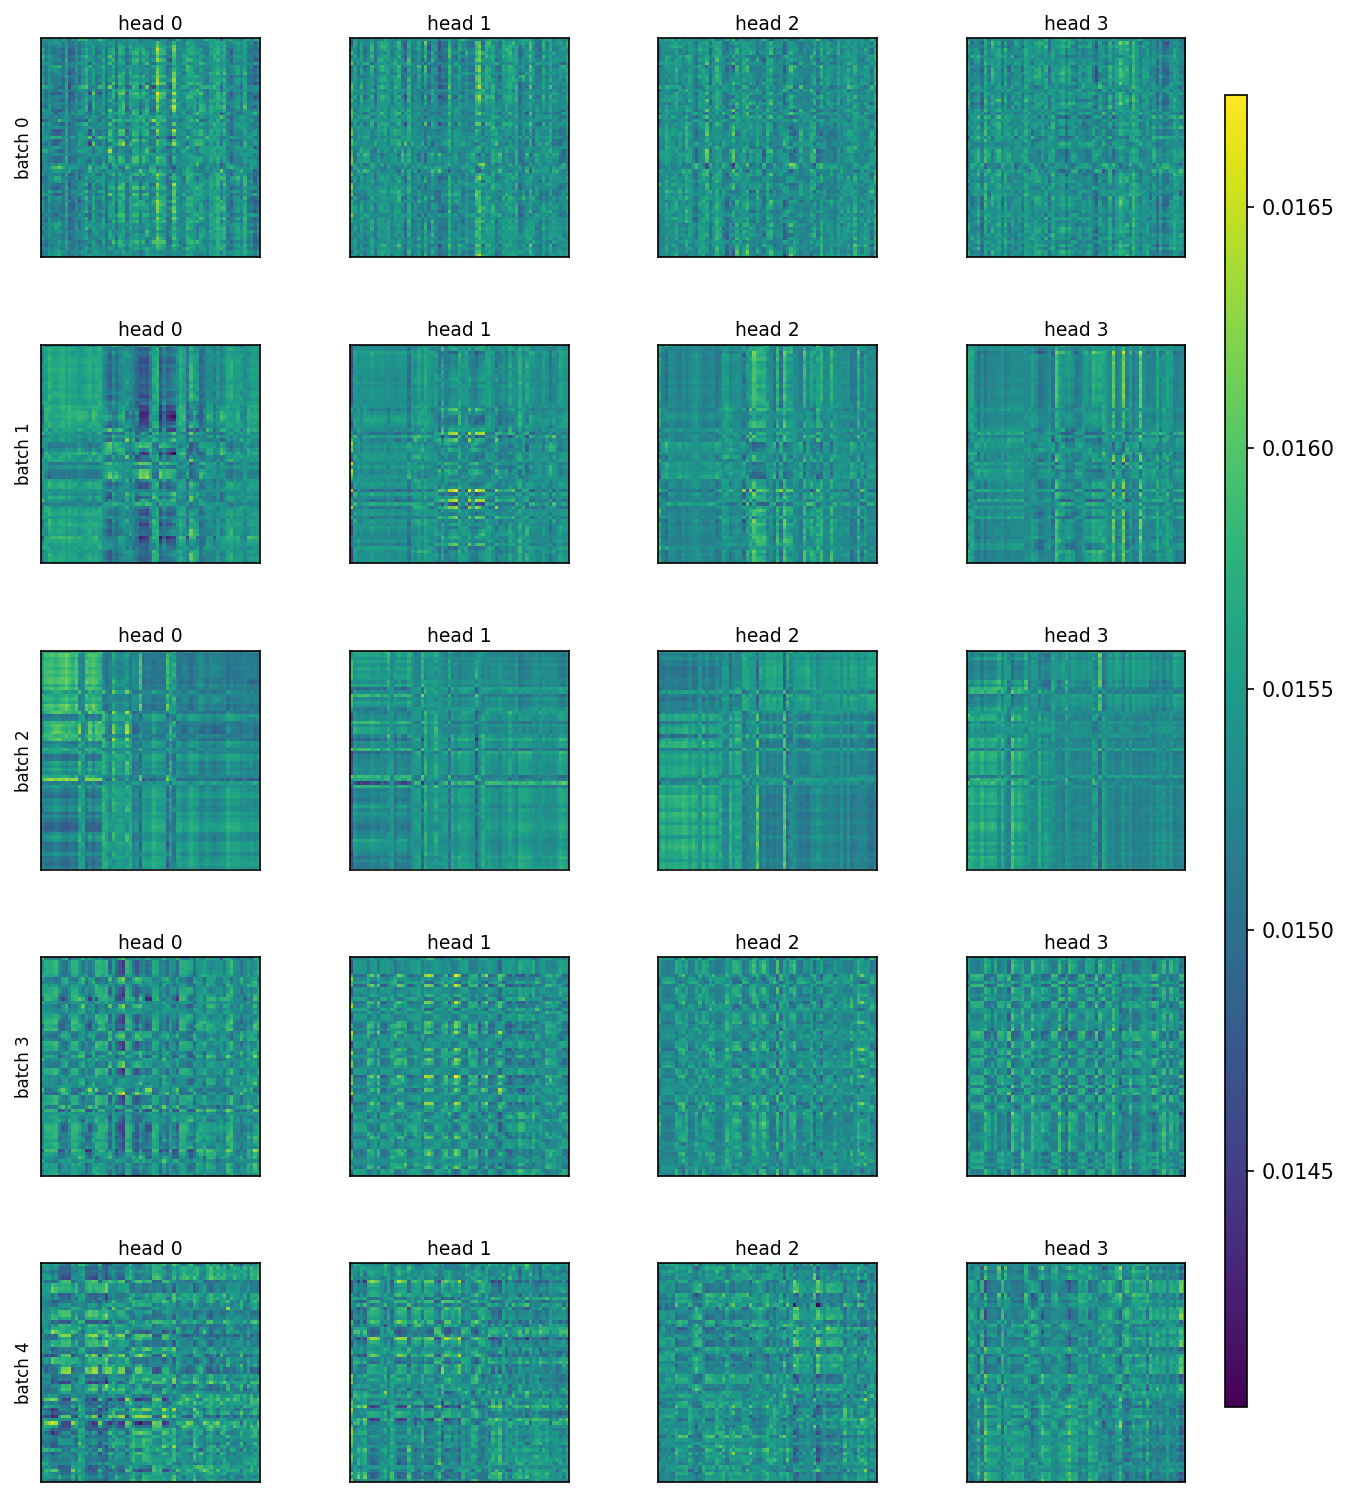

In [10]:
visualize_attention(attention_maps[0])

In [11]:
attention_maps[0].shape

torch.Size([5, 4, 65, 65])

In [12]:
dataset.get_samples_from_indices(INDICES)[0].shape

torch.Size([5, 3, 32, 32])

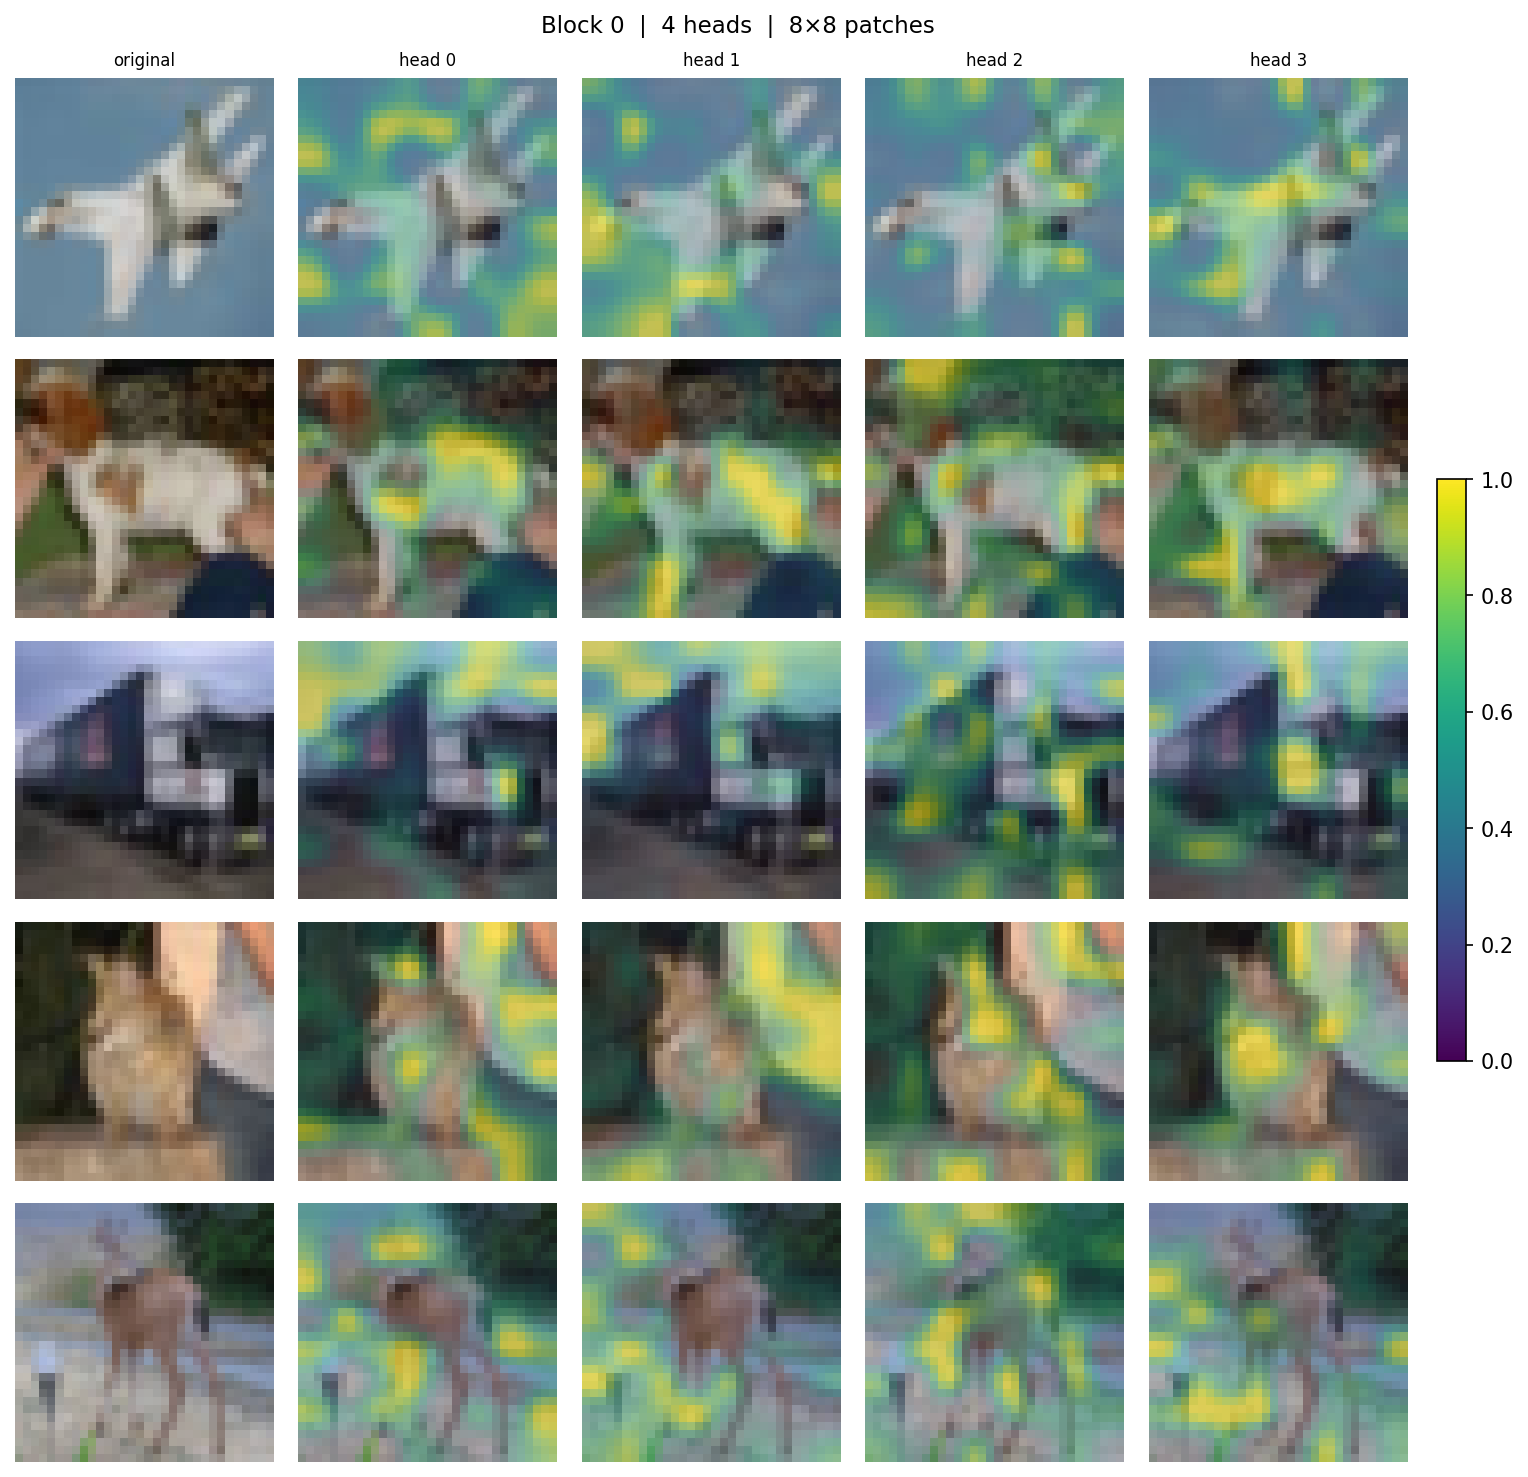

In [13]:
visualize_attention_on_images(attention_maps[0], dataset.get_samples_from_indices(INDICES)[0])[0]

In [19]:
is_interpretable = False #@param {type:"boolean"}
epochs = 15 #@param {type: "integer"}
exp_name = f'vit-with-{epochs}-epochs{"-interpretable" if is_interpretable else ""}-{dataset.name}' #@param {type:"string"}
batch_size = 32 #@param {type: "integer"}
lr = 1e-2  #@param {type: "number"}
save_model_every = 0 #@param {type: "integer"}
lambda_loss = 0.7 #@param {type: "number"}

mlflow.set_experiment(exp_name)

config = {
    "patch_size": 4,  # Input image size: 32x32 -> 8x8 patches
    "hidden_size": 48,
    "num_hidden_layers": 4,
    "num_attention_heads": 4,
    "intermediate_size": 4 * 48, # 4 * hidden_size
    "hidden_dropout_prob": 0.0,
    "attention_probs_dropout_prob": 0.0,
    "initializer_range": 0.02,
    "image_size": 32,
    "num_classes": 10, # num_classes of CIFAR10
    "num_channels": 3,
    "qkv_bias": True,
    "use_faster_attention": False,
}
assert config["hidden_size"] % config["num_attention_heads"] == 0
assert config['intermediate_size'] == 4 * config['hidden_size']
assert config['image_size'] % config['patch_size'] == 0

2026/04/19 17:22:32 INFO mlflow.tracking.fluent: Experiment with name 'vit-with-15-epochs-CIFAR10' does not exist. Creating a new experiment.


In [20]:
def interpretability_loss(attention_maps):
    # attention_maps: (B, H, P) — atención del CLS hacia los parches por cada cabeza

    B, H, P = attention_maps.shape

    # Normalización L2 antes del producto punto entre cabezas.
    # Así la similitud queda en [-1, 1] (similitud coseno) y no depende de la magnitud
    # absoluta del vector de atención — evita que el modelo reduzca la loss
    # simplemente achicando los valores de atención.
    attention_maps = F.normalize(attention_maps, p=2, dim=-1)

    # Producto punto entre todos los pares de cabezas (i, j) posición a posición
    mm = torch.einsum('bhp,bkp->bhkp', attention_maps, attention_maps)

    # Máscara [H, H] → True en diagonal (no comparar cabeza consigo misma)
    diag_mask = torch.eye(H, dtype=torch.bool, device=attention_maps.device)

    # Anular la diagonal para que no contribuya a la loss
    mm_masked = mm.clone()
    mm_masked[:, diag_mask, :] = float(0)

    mm_sum = mm_masked.sum(dim=(1, 2))   # (B, P)
    mm_total = mm_sum.sum(dim=1)          # (B,)  una pérdida por imagen

    # Reducir a escalar para que .backward() funcione.
    # mean() mantiene la magnitud del gradiente independiente del batch size.
    return mm_total.mean()

In [21]:
logger = logging.getLogger(__name__)

In [22]:
class Trainer:
    """
    The simple trainer.
    """

    def __init__(self, model, optimizer, loss_fn, exp_name, device, dataset=None, log_indices=None):
        self.model = model.to(device)
        self.optimizer = optimizer
        self.loss_fn = loss_fn
        self.exp_name = exp_name
        self.device = device
        self.dataset = dataset
        self.log_indices = log_indices

    def train(self, trainloader, testloader, epochs, save_model_every_n_epochs=0):
        list_train_diversity_losses = []
        list_train_losses = []
        list_test_losses = []
        list_test_diversity_losses = []

        with mlflow.start_run(run_name="run-experiment"):
            mlflow.log_param("epochs", epochs)
            mlflow.log_param("batch_size", batch_size)
            mlflow.log_param("learning_rate", lr)
            mlflow.log_param("lambda_loss", lambda_loss)

            for i in range(epochs):
                train_losses = self.train_epoch(trainloader, epoch_i=i)
                test_losses = self.evaluate(testloader, epoch_i=i)

                logger.info(f"Epoch {i+1}/{epochs} - Train Loss: {train_losses['total_loss']:.4f}, "
                            f"Train Diversity Loss: {train_losses['interpretability_loss']:.4f}, "
                            f"Test Loss: {test_losses['total_loss']:.4f}, "
                            f"Test Accuracy: {test_losses['accuracy']:.4f}")

                if save_model_every_n_epochs > 0 and (i+1) % save_model_every_n_epochs == 0 and i+1 != epochs:
                    print("	Save checkpoint at epoch", i+1)
                    save_checkpoint(self.exp_name, self.model, i+1)

        save_experiment(self.exp_name, config, self.model, test_losses, base_dir="experiments")
    def train_epoch(self, trainloader, epoch_i=0):
        self.model.train()
        losses = {
            "cls_loss": [],
            "interpretability_loss": [],
            "total_loss": [],
        }

        for batch in trainloader:
            batch = [t.to(self.device) for t in batch]
            images, labels = batch
            self.optimizer.zero_grad()

            logits, attention_maps = self.model(images, output_attentions=True)

            interpretability_loss_value = interpretability_loss(attention_maps[-1][:, :, 0, 1:])
            cls_loss = self.loss_fn(logits, labels)

            if is_interpretable:
                total_loss = (1 - lambda_loss) * cls_loss + lambda_loss * interpretability_loss_value
            else:
                total_loss = cls_loss

            total_loss.backward()
            self.optimizer.step()

            losses["cls_loss"].append(cls_loss.item())
            losses["interpretability_loss"].append(interpretability_loss_value.item())
            losses["total_loss"].append(total_loss.item())

        avg_cls_loss = sum(losses["cls_loss"]) / len(losses["cls_loss"])
        avg_interpretability_loss = sum(losses["interpretability_loss"]) / len(losses["interpretability_loss"])
        avg_total_loss = sum(losses["total_loss"]) / len(losses["total_loss"])

        mlflow.log_metric("loss", avg_cls_loss, step=epoch_i)
        mlflow.log_metric("interpretability_loss", avg_interpretability_loss, step=epoch_i)
        mlflow.log_metric("total_loss", avg_total_loss, step=epoch_i)

        return {
            "cls_loss": avg_cls_loss,
            "interpretability_loss": avg_interpretability_loss,
            "total_loss": avg_total_loss
        }

    @torch.no_grad()
    def evaluate(self, testloader, epoch_i=0):
        self.model.eval()

        losses = {
            "cls_loss": [],
            "interpretability_loss": [],
            "total_loss": [],
        }

        # Acumuladores para accuracy y matriz de confusión.
        # La confusión la armamos en CPU para no transferir tensores por batch.
        num_classes = config["num_classes"]
        confusion = torch.zeros(num_classes, num_classes, dtype=torch.long)
        total_correct = 0
        total_samples = 0

        for batch in testloader:
            batch = [t.to(self.device) for t in batch]
            images, labels = batch

            logits, attention_maps = self.model(images, output_attentions=True)
            # Misma señal que en train: atención del CLS (pos 0) hacia los parches (1:) en la última capa
            interpretability_loss_value = interpretability_loss(attention_maps[-1][:, :, 0, 1:])
            cls_loss = self.loss_fn(logits, labels)

            if is_interpretable:
                total_loss = (1 - lambda_loss) * cls_loss + lambda_loss * interpretability_loss_value
            else:
                total_loss = cls_loss

            losses["cls_loss"].append(cls_loss.item())
            losses["interpretability_loss"].append(interpretability_loss_value.item())
            losses["total_loss"].append(total_loss.item())

            # Predicción por sample
            preds = logits.argmax(dim=-1)

            # Accuracy
            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

            # Matriz de confusión acumulada vía bincount (O(N) por batch, sin loop Python).
            # Truco: index = true * num_classes + pred → bin único por celda (true, pred).
            idx = labels * num_classes + preds
            binc = torch.bincount(idx, minlength=num_classes * num_classes).cpu()
            confusion += binc.view(num_classes, num_classes)

        avg_cls_loss = sum(losses["cls_loss"]) / len(losses["cls_loss"])
        avg_interpretability_loss = sum(losses["interpretability_loss"]) / len(losses["interpretability_loss"])
        avg_total_loss = sum(losses["total_loss"]) / len(losses["total_loss"])
        accuracy = total_correct / total_samples

        mlflow.log_metric("val_loss", avg_cls_loss, step=epoch_i)
        mlflow.log_metric("val_interpretability_loss", avg_interpretability_loss, step=epoch_i)
        mlflow.log_metric("val_total_loss", avg_total_loss, step=epoch_i)
        mlflow.log_metric("val_accuracy", accuracy, step=epoch_i)

        # --- Matriz de confusión como imagen ---
        # Normalizamos por fila (true class): cada celda (i, j) es la proporción de la
        # clase i que fue clasificada como j. La diagonal pasa a ser el recall por clase.
        cm = confusion.float()
        cm_norm = cm / cm.sum(dim=1, keepdim=True).clamp(min=1)
        cm_np = cm_norm.numpy()

        class_names = getattr(self.dataset, "classes", None) if self.dataset is not None else None
        if class_names is None:
            class_names = [str(i) for i in range(num_classes)]

        fig, ax = plt.subplots(figsize=(8, 7))
        im = ax.imshow(cm_np, cmap="Blues", vmin=0, vmax=1)
        ax.set_title(f"Confusion matrix (row-normalized) — epoch {epoch_i}")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        ax.set_xticks(range(num_classes))
        ax.set_yticks(range(num_classes))
        ax.set_xticklabels(class_names, rotation=45, ha="right")
        ax.set_yticklabels(class_names)

        # Anotar cada celda con su proporción
        for i in range(num_classes):
            for j in range(num_classes):
                val = cm_np[i, j]
                ax.text(j, i, f"{val:.2f}",
                        ha="center", va="center",
                        fontsize=8,
                        color="white" if val > 0.5 else "black")

        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        fig.tight_layout()

        mlflow.log_figure(fig, f"confusion_matrix/epoch_{epoch_i:03d}.png")
        plt.close(fig)

        # Log attention
        if self.dataset is not None and self.log_indices is not None:
            log_images, _ = self.dataset.get_samples_from_indices(self.log_indices, device=self.device)
            _, log_attention_maps = self.model(log_images, output_attentions=True)

            for layer_idx, amap in enumerate(log_attention_maps):
                attn_img = visualize_attention(amap)
                mlflow.log_image(attn_img, f"attention/layer_{layer_idx}/epoch_{epoch_i:03d}.png")

            overlay_imgs = visualize_attention_on_images(log_attention_maps, log_images)
            for layer_idx, overlay_img in enumerate(overlay_imgs):
                mlflow.log_image(overlay_img, f"attention_overlay/layer_{layer_idx}/epoch_{epoch_i:03d}.png")

        return {
            "cls_loss": avg_cls_loss,
            "interpretability_loss": avg_interpretability_loss,
            "total_loss": avg_total_loss,
            "accuracy": accuracy
        }


In [23]:
save_model_every_n_epochs = save_model_every
trainloader, testloader, _ = dataset.get_loaders(batch_size=batch_size, num_workers=4)
model = ViTForClassfication(config)


/Users/valefeve/Projects/interpretable-transformers/venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [24]:
from torchviz import make_dot
import torch

x = torch.randn(1, 3, 32, 32)
y, _ = model(x)
dot = make_dot(y, params=dict(model.named_parameters()))
dot.render("vit_graph", format="png")

'vit_graph.png'

In [25]:

optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
loss_fn = nn.CrossEntropyLoss()
trainer = Trainer(model, optimizer, loss_fn, exp_name, device=device, dataset=dataset, log_indices=INDICES)
trainer.train(trainloader, testloader, epochs, save_model_every_n_epochs=save_model_every_n_epochs)


In [26]:
mlflow.end_run()

In [27]:
current_date = datetime.now().strftime("%Y-%m-%d-%H-%M-%S")
torch.save(model.state_dict(), f"vit_final_{current_date}.pt")